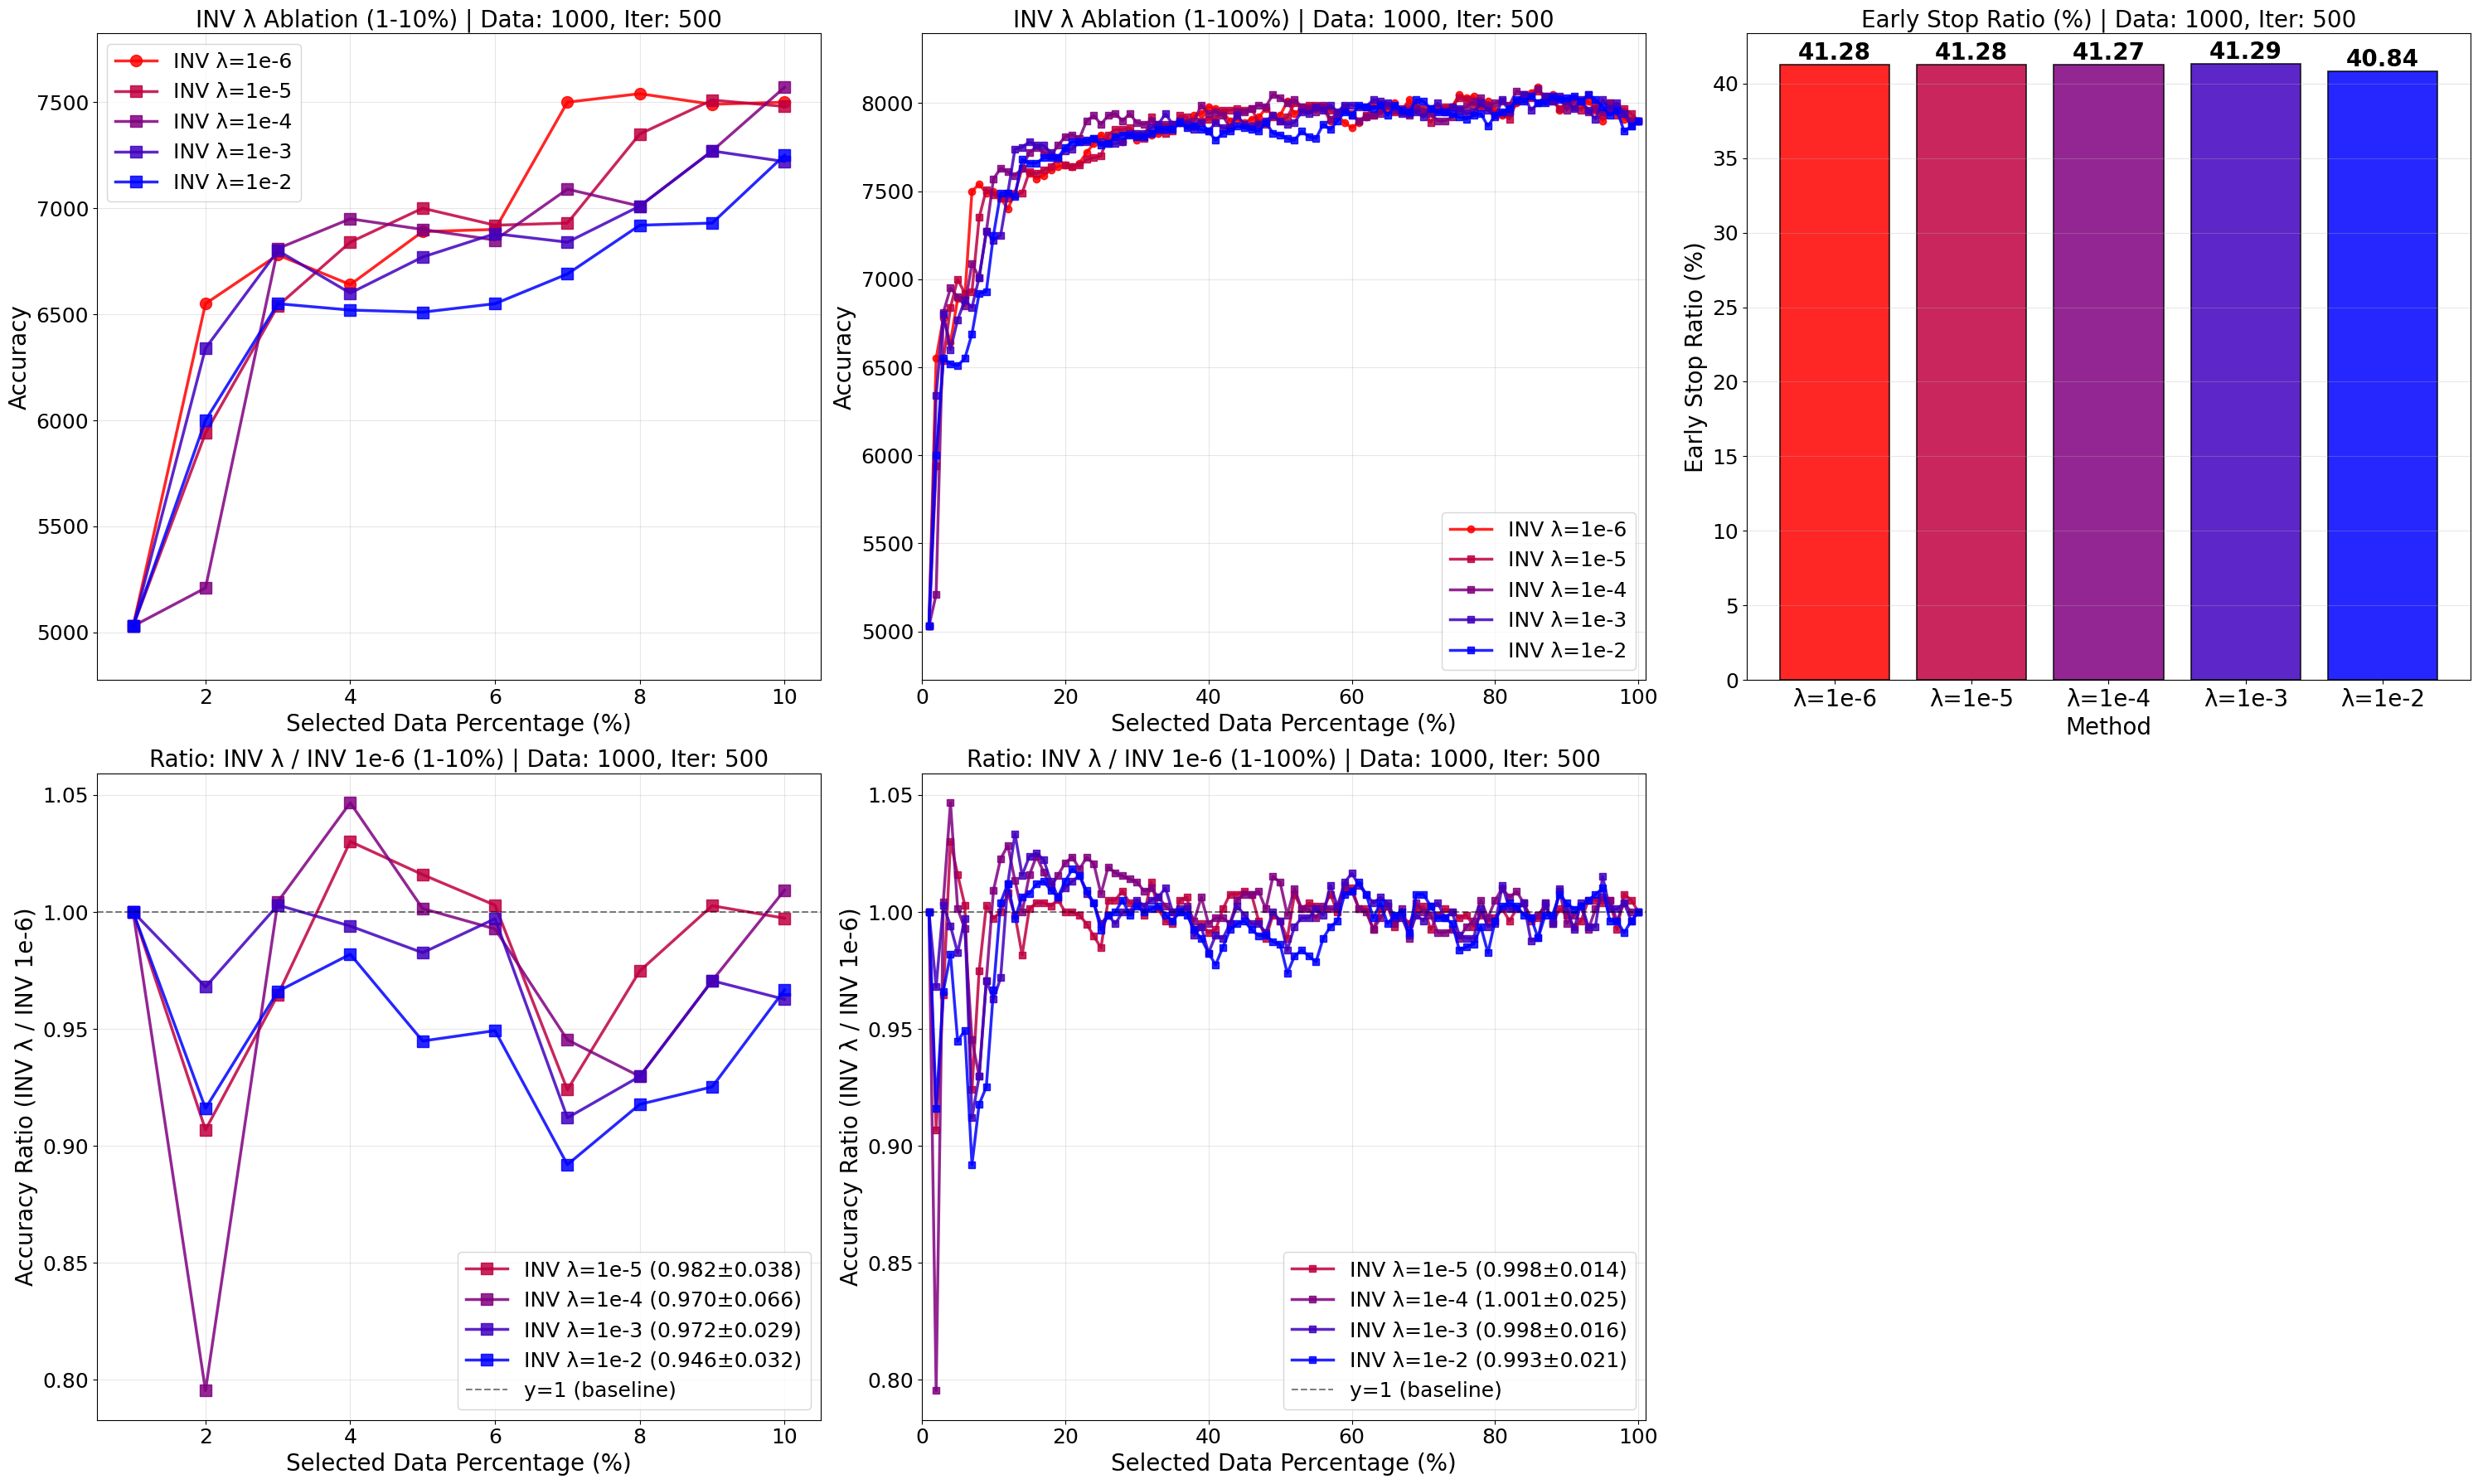

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors

# ===== Configuration =====
num_dp = 1000
iteration = 500
# =========================

selected_dp_percent = [i for i in range(1, 101)]

# inv lambda: variable, inv lambda: fixed(1e-6)
lam1e_6  = [5030, 6550, 6780, 6640, 6890, 6900, 7500, 7540, 7490, 7500, 7460, 7400, 7490, 7630, 7600, 7570, 7590, 7620, 7640, 7650, 7640, 7660, 7720, 7770, 7820, 7780, 7810, 7780, 7830, 7790, 7810, 7820, 7830, 7860, 7880, 7890, 7870, 7930, 7940, 7980, 7970, 7950, 7900, 7910, 7890, 7910, 7920, 7970, 7930, 7930, 8010, 7940, 7970, 7960, 7970, 7970, 7900, 7930, 7890, 7860, 7890, 7920, 7990, 7960, 7970, 8000, 7960, 8020, 7960, 7950, 7950, 7970, 7970, 7980, 8050, 8030, 8040, 7990, 8010, 7960, 7930, 7940, 8000, 8020, 8060, 8090, 8010, 8050, 7960, 8000, 8030, 7990, 8010, 7960, 7900, 7960, 7990, 7910, 7900, 7900]
lam1e_5  = [5030, 5940, 6540, 6840, 7000, 6920, 6930, 7350, 7510, 7480, 7460, 7460, 7480, 7490, 7610, 7600, 7620, 7640, 7680, 7650, 7640, 7650, 7680, 7690, 7700, 7820, 7850, 7850, 7860, 7820, 7800, 7920, 7840, 7830, 7840, 7930, 7920, 7870, 7900, 7910, 7910, 7960, 7960, 7970, 7960, 7970, 7890, 7880, 7920, 7900, 7920, 8000, 7980, 7990, 7990, 7980, 7960, 7930, 7960, 7940, 7900, 7930, 7930, 7970, 7990, 7950, 7950, 7980, 7970, 7970, 7890, 7960, 7980, 7980, 8030, 8020, 7990, 7980, 7980, 7940, 7940, 7910, 8010, 8050, 8030, 8070, 8040, 8010, 7970, 7990, 7980, 7960, 8050, 8000, 7930, 8000, 7930, 7970, 7940, 7900]
lam1e_4  = [5030, 5210, 6810, 6950, 6900, 6850, 7090, 7010, 7270, 7570, 7630, 7610, 7590, 7630, 7720, 7750, 7720, 7700, 7760, 7810, 7820, 7800, 7900, 7930, 7880, 7930, 7940, 7900, 7940, 7890, 7880, 7900, 7880, 7880, 7880, 7890, 7890, 7900, 7990, 7940, 7950, 7930, 7860, 7950, 7950, 7970, 7990, 7980, 8050, 8030, 8000, 8020, 7980, 7970, 7950, 7990, 7910, 7940, 7980, 7930, 7900, 7920, 7930, 7940, 7990, 7960, 7970, 7930, 7990, 7950, 7940, 7900, 7900, 7920, 7960, 7980, 8010, 8030, 7990, 8000, 8010, 7990, 8070, 8050, 8040, 8080, 8030, 8020, 8030, 7960, 8020, 8010, 7950, 7970, 7950, 8000, 7960, 7940, 7900, 7900]
lam1e_3  = [5030, 6340, 6800, 6600, 6770, 6880, 6840, 7010, 7270, 7220, 7250, 7490, 7740, 7750, 7780, 7760, 7760, 7720, 7690, 7730, 7740, 7780, 7780, 7800, 7780, 7770, 7770, 7780, 7830, 7830, 7830, 7860, 7880, 7940, 7880, 7900, 7880, 7850, 7890, 7840, 7890, 7860, 7860, 7930, 7880, 7870, 7880, 7900, 7930, 7900, 7880, 7890, 7950, 7940, 7980, 7960, 7990, 7950, 7990, 7990, 7980, 7980, 8020, 8010, 8000, 7980, 7940, 7940, 7950, 7920, 7970, 8000, 7950, 7980, 7970, 7940, 7950, 8000, 7960, 7920, 8020, 7950, 8010, 8050, 7960, 8000, 8040, 8010, 8040, 8010, 7970, 8020, 7960, 7910, 8020, 7970, 8000, 7940, 7870, 7900]
lam1e_2  = [5030, 6000, 6550, 6520, 6510, 6550, 6690, 6920, 6930, 7250, 7490, 7490, 7470, 7680, 7660, 7660, 7690, 7690, 7690, 7750, 7780, 7780, 7790, 7800, 7760, 7770, 7810, 7820, 7820, 7810, 7810, 7830, 7850, 7850, 7850, 7890, 7860, 7870, 7850, 7840, 7790, 7830, 7840, 7870, 7860, 7850, 7840, 7890, 7830, 7820, 7800, 7790, 7840, 7810, 7800, 7880, 7850, 7900, 7950, 7930, 7990, 7980, 7970, 7990, 7930, 7990, 7960, 7950, 8020, 8010, 7970, 7950, 7950, 7940, 7920, 7910, 7930, 7940, 7870, 7930, 7950, 7970, 8020, 8010, 8040, 8000, 8000, 8040, 8020, 8030, 8040, 8010, 8050, 8020, 7980, 7930, 7960, 7840, 7870, 7900]

lam1e_6_early_stop = [41.28]
lam1e_5_early_stop = [41.28]
lam1e_4_early_stop = [41.27]
lam1e_3_early_stop = [41.29]
lam1e_2_early_stop = [40.84]

# ===== Color scheme: λ=1e-6 (red) ~ λ=1e-2 (blue) interpolation =====
color_1e_6 = np.array(mcolors.to_rgb('red'))
color_1e_2 = np.array(mcolors.to_rgb('blue'))

def interp_color(t):
    return tuple((1 - t) * color_1e_6 + t * color_1e_2)

# λ=1e-6: t=0 (red), λ=1e-5: t=0.25, λ=1e-4: t=0.5, λ=1e-3: t=0.75, λ=1e-2: t=1.0 (blue)
lam_colors = {
    '1e-6': interp_color(0.0),
    '1e-5': interp_color(0.25),
    '1e-4': interp_color(0.5),
    '1e-3': interp_color(0.75),
    '1e-2': interp_color(1.0),
}

# Data and labels for comparison (λ=1e-5 ~ 1e-2 vs baseline λ=1e-6)
inv_data = [
    (lam1e_5, 'INV λ=1e-5', lam_colors['1e-5']),
    (lam1e_4, 'INV λ=1e-4', lam_colors['1e-4']),
    (lam1e_3, 'INV λ=1e-3', lam_colors['1e-3']),
    (lam1e_2, 'INV λ=1e-2', lam_colors['1e-2']),
]

# Create figure with 6 subplots (2 rows, 3 columns)
fig, axes = plt.subplots(2, 3, figsize=(30, 18))
axes = axes.flatten()

plot_percent_10 = selected_dp_percent[:10]

# ===== Subplot (1,1): INV λ별 prediction accuracy, 1~10% =====
ax1 = axes[0]

ax1.plot(plot_percent_10, lam1e_6[:10], color=lam_colors['1e-6'], linewidth=2.5,
         linestyle='-', marker='o', markersize=10, label='INV λ=1e-6', alpha=0.85)

for data, label, color in inv_data:
    ax1.plot(plot_percent_10, data[:10], color=color, linewidth=2.5,
             linestyle='-', marker='s', markersize=10, label=label, alpha=0.85)

all_data_10 = [lam1e_6[:10]] + [d[0][:10] for d in inv_data]
y_min_10 = min([min(d) for d in all_data_10])
y_max_10 = max([max(d) for d in all_data_10])
y_margin_10 = (y_max_10 - y_min_10) * 0.1
ylim_10_min = y_min_10 - y_margin_10
ylim_10_max = y_max_10 + y_margin_10

ax1.set_xlabel('Selected Data Percentage (%)', fontsize=20)
ax1.set_ylabel('Accuracy', fontsize=20)
ax1.set_title(f'INV λ Ablation (1-10%) | Data: {num_dp}, Iter: {iteration}', fontsize=20)
ax1.legend(fontsize=18, loc='best')
ax1.grid(True, alpha=0.3)
ax1.set_xlim(0.5, 10.5)
ax1.set_ylim(ylim_10_min, ylim_10_max)
ax1.tick_params(axis='both', labelsize=18)

# ===== Subplot (1,2): INV λ별 prediction accuracy, 1~100% =====
ax2 = axes[1]

ax2.plot(selected_dp_percent, lam1e_6, color=lam_colors['1e-6'], linewidth=2.5,
         linestyle='-', marker='o', markersize=6, label='INV λ=1e-6', alpha=0.85)

for data, label, color in inv_data:
    ax2.plot(selected_dp_percent, data, color=color, linewidth=2.5,
             linestyle='-', marker='s', markersize=6, label=label, alpha=0.85)

all_data_100 = [lam1e_6] + [d[0] for d in inv_data]
y_min_100 = min([min(d) for d in all_data_100])
y_max_100 = max([max(d) for d in all_data_100])
y_margin_100 = (y_max_100 - y_min_100) * 0.1
ylim_100_min = y_min_100 - y_margin_100
ylim_100_max = y_max_100 + y_margin_100

ax2.set_xlabel('Selected Data Percentage (%)', fontsize=20)
ax2.set_ylabel('Accuracy', fontsize=20)
ax2.set_title(f'INV λ Ablation (1-100%) | Data: {num_dp}, Iter: {iteration}', fontsize=20)
ax2.legend(fontsize=18, loc='best')
ax2.grid(True, alpha=0.3)
ax2.set_xlim(0, 101)
ax2.set_ylim(ylim_100_min, ylim_100_max)
ax2.tick_params(axis='both', labelsize=18)

# ===== Subplot (1,3): Early Stop Ratio =====
ax3 = axes[2]

method_names = ['λ=1e-6', 'λ=1e-5', 'λ=1e-4', 'λ=1e-3', 'λ=1e-2']
method_values = [
    lam1e_6_early_stop[0],
    lam1e_5_early_stop[0],
    lam1e_4_early_stop[0],
    lam1e_3_early_stop[0],
    lam1e_2_early_stop[0],
]
bar_colors = [lam_colors['1e-6'], lam_colors['1e-5'], lam_colors['1e-4'], lam_colors['1e-3'], lam_colors['1e-2']]

x_pos = np.arange(len(method_names))
bars = ax3.bar(x_pos, method_values, color=bar_colors, alpha=0.85, edgecolor='black', linewidth=1.2)

for bar, value in zip(bars, method_values):
    height = bar.get_height()
    ax3.text(bar.get_x() + bar.get_width()/2., height,
             f'{value:.2f}', ha='center', va='bottom', fontsize=20, fontweight='bold')

ax3.set_xlabel('Method', fontsize=20)
ax3.set_ylabel('Early Stop Ratio (%)', fontsize=20)
ax3.set_title(f'Early Stop Ratio (%) | Data: {num_dp}, Iter: {iteration}', fontsize=20)
ax3.set_xticks(x_pos)
ax3.set_xticklabels(method_names, fontsize=20)
ax3.grid(True, alpha=0.3, axis='y')
ax3.tick_params(axis='y', labelsize=18)

# ===== Subplot (2,1): Ratio (INV 1e-X / INV 1e-6), 1~10% =====
ax4 = axes[3]

for data, label, color in inv_data:
    ratios = np.array(data[:10]) / np.array(lam1e_6[:10])
    ratio_mean = np.mean(ratios)
    ratio_std = np.std(ratios)
    ax4.plot(plot_percent_10, ratios, color=color, linewidth=2.5,
             linestyle='-', marker='s', markersize=10,
             label=f'{label} ({ratio_mean:.3f}±{ratio_std:.3f})', alpha=0.85)

ax4.axhline(y=1.0, color='black', linestyle='--', linewidth=1.5, alpha=0.5, label='y=1 (baseline)')

ax4.set_xlabel('Selected Data Percentage (%)', fontsize=20)
ax4.set_ylabel('Accuracy Ratio (INV λ / INV 1e-6)', fontsize=20)
ax4.set_title(f'Ratio: INV λ / INV 1e-6 (1-10%) | Data: {num_dp}, Iter: {iteration}', fontsize=20)
ax4.legend(fontsize=18, loc='best')
ax4.grid(True, alpha=0.3)
ax4.set_xlim(0.5, 10.5)
ax4.tick_params(axis='both', labelsize=18)

# ===== Subplot (2,2): Ratio (INV 1e-X / INV 1e-6), 1~100% =====
ax5 = axes[4]

for data, label, color in inv_data:
    ratios = np.array(data) / np.array(lam1e_6)
    ratio_mean = np.mean(ratios)
    ratio_std = np.std(ratios)
    ax5.plot(selected_dp_percent, ratios, color=color, linewidth=2.5,
             linestyle='-', marker='s', markersize=6,
             label=f'{label} ({ratio_mean:.3f}±{ratio_std:.3f})', alpha=0.85)

ax5.axhline(y=1.0, color='black', linestyle='--', linewidth=1.5, alpha=0.5, label='y=1 (baseline)')

ax5.set_xlabel('Selected Data Percentage (%)', fontsize=20)
ax5.set_ylabel('Accuracy Ratio (INV λ / INV 1e-6)', fontsize=20)
ax5.set_title(f'Ratio: INV λ / INV 1e-6 (1-100%) | Data: {num_dp}, Iter: {iteration}', fontsize=20)
ax5.legend(fontsize=18, loc='best')
ax5.grid(True, alpha=0.3)
ax5.set_xlim(0, 101)
ax5.tick_params(axis='both', labelsize=18)

# ===== Subplot (2,3): Turn off unused subplot =====
axes[5].axis('off')

plt.tight_layout()
plt.show()

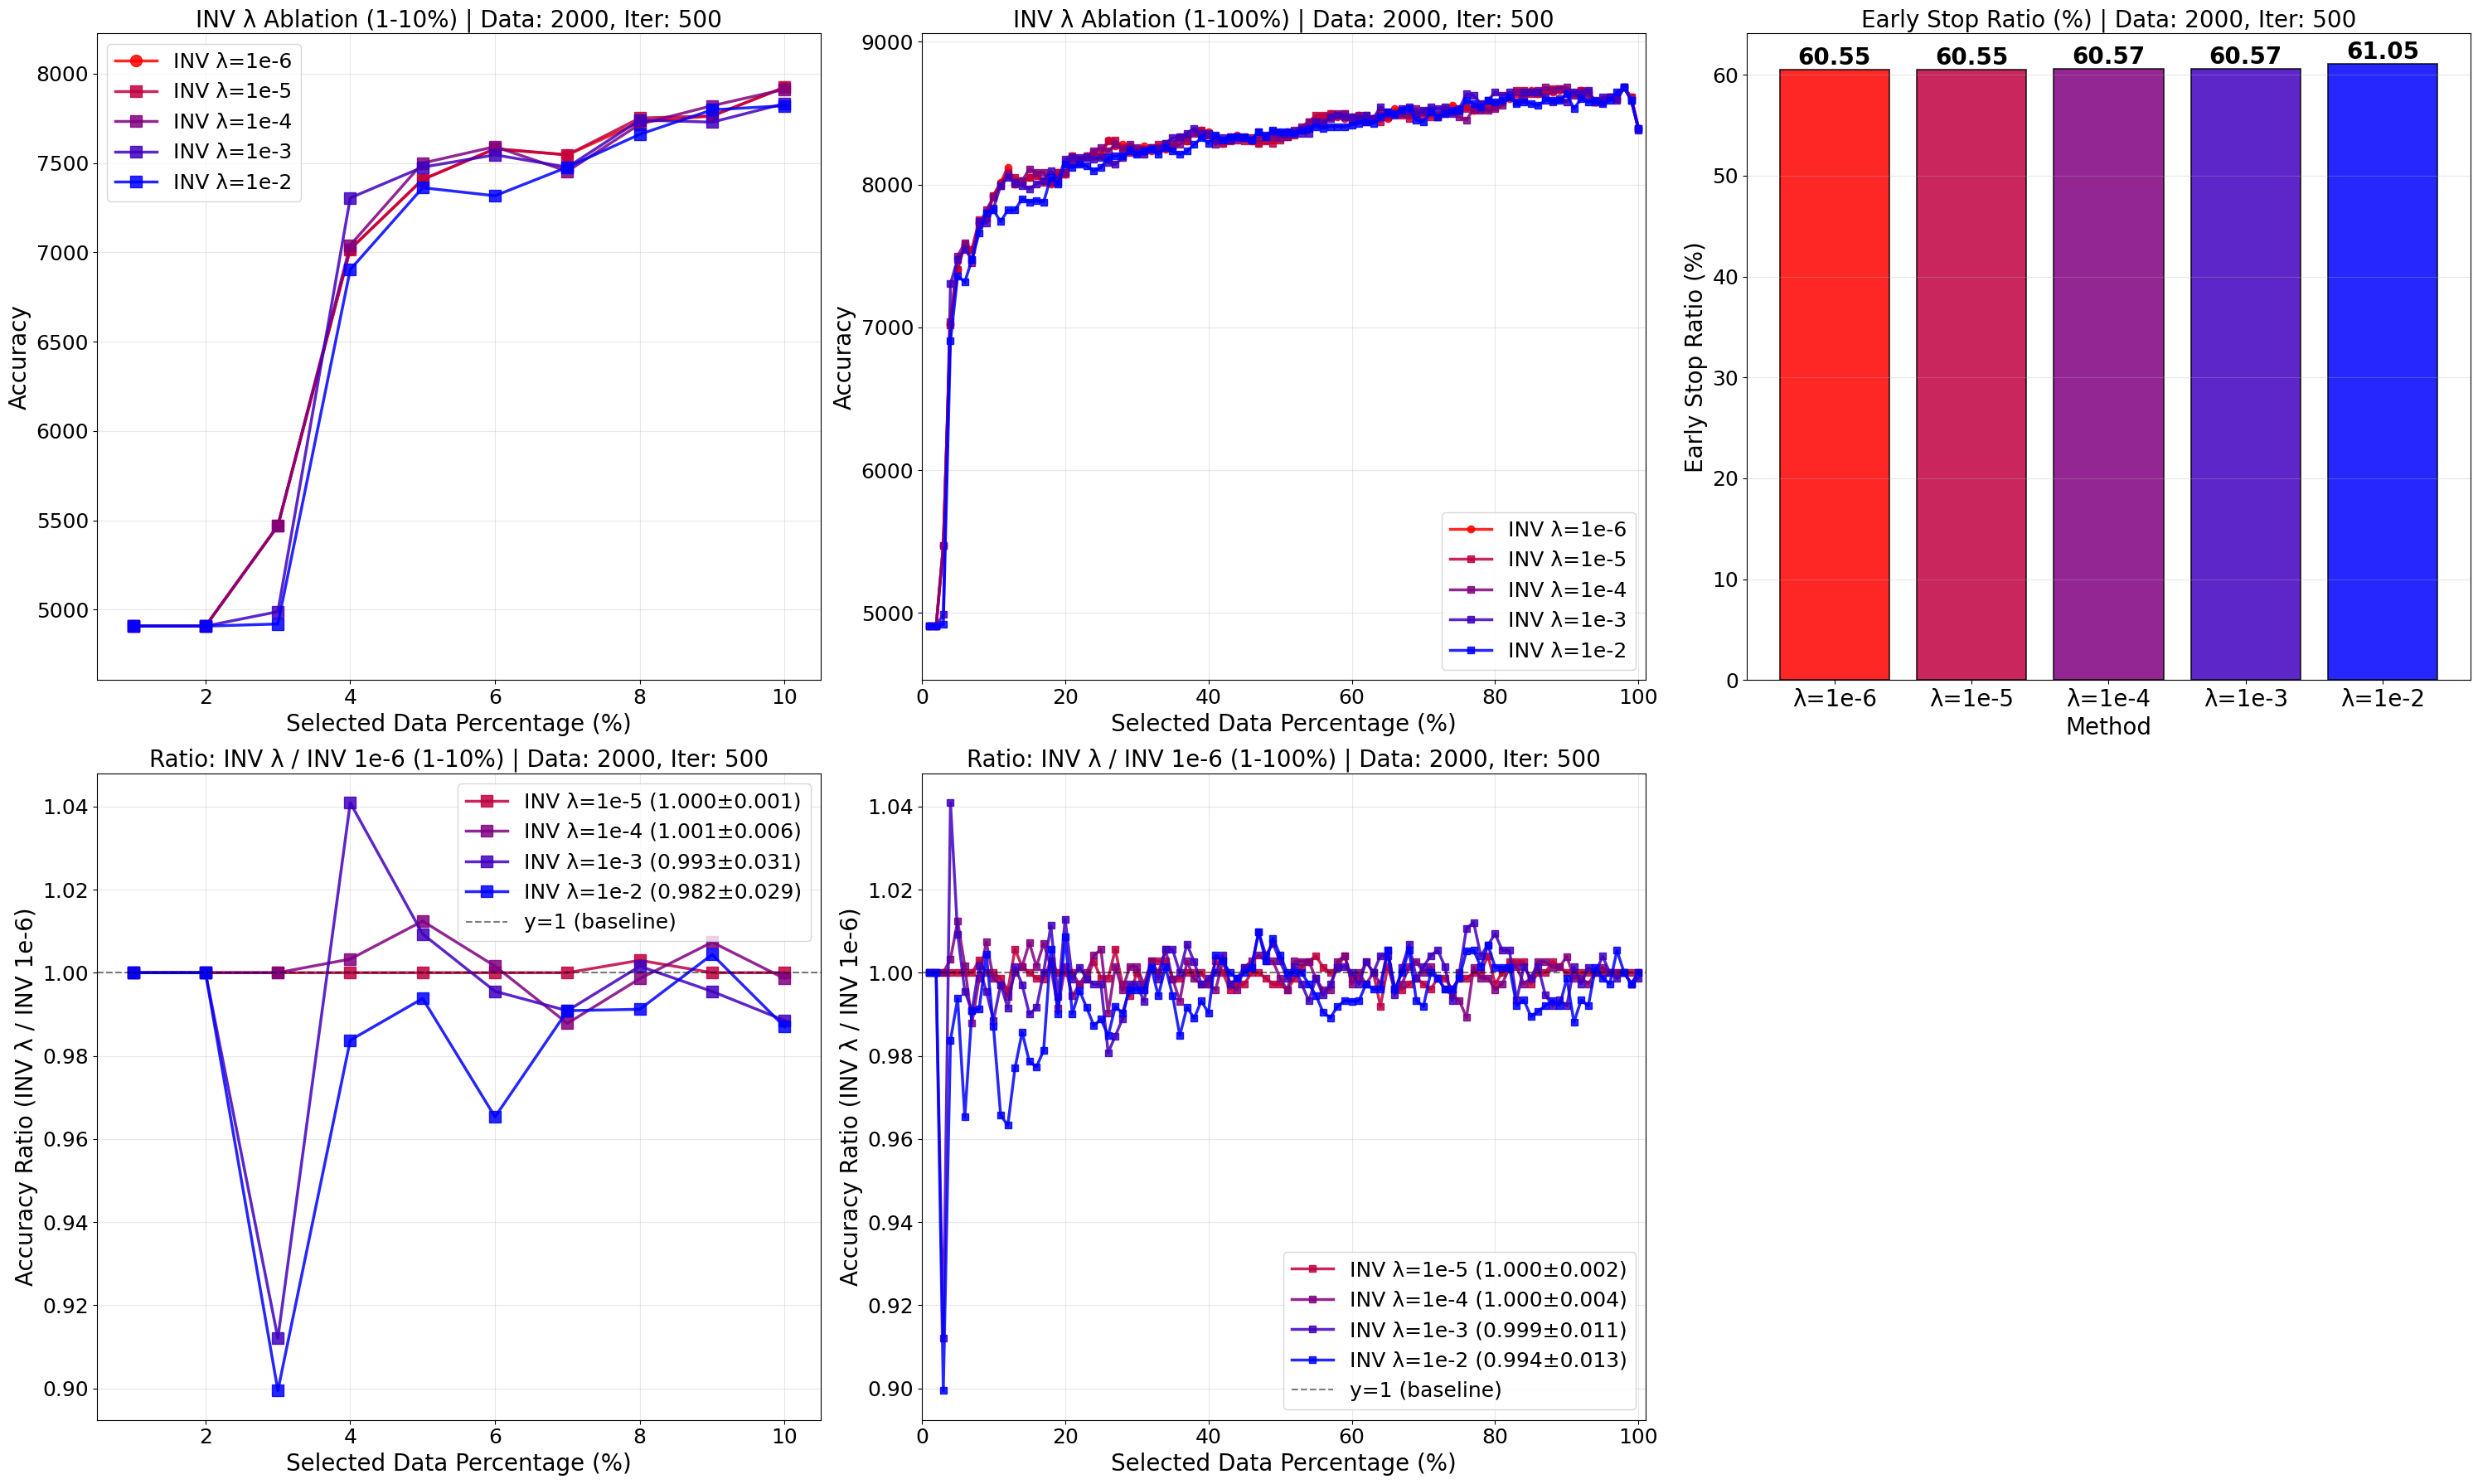

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors

# ===== Configuration =====
num_dp = 2000
iteration = 500
# =========================

selected_dp_percent = [i for i in range(1, 101)]

# inv lambda: variable, inv lambda: fixed(1e-6)
lam1e_6  = [7290, 7500, 7680, 7670, 7730, 7730, 7840, 7820, 7790, 7860, 7800, 7840, 7800, 7870, 7830, 7840, 7890, 7900, 7880, 7950, 7940, 7910, 7910, 7980, 7980, 8070, 8070, 8100, 8050, 8070, 8090, 8080, 8070, 8070, 8090, 8110, 8090, 8120, 8100, 8100, 8090, 8090, 8110, 8120, 8150, 8140, 8100, 8130, 8100, 8140, 8120, 8120, 8160, 8160, 8140, 8180, 8170, 8150, 8130, 8150, 8210, 8180, 8100, 8150, 8200, 8190, 8170, 8170, 8150, 8140, 8120, 8140, 8150, 8190, 8190, 8240, 8250, 8170, 8200, 8200, 8140, 8160, 8150, 8150, 8130, 8140, 8150, 8170, 8150, 8160, 8220, 8130, 8020, 8050, 7900, 7980, 7970, 7930, 7900, 7970]
lam1e_5  = [6950, 7530, 7710, 7750, 7740, 7760, 7870, 7900, 7830, 7860, 7850, 7800, 7810, 7840, 7910, 7870, 7960, 7950, 8050, 8040, 8040, 8050, 8050, 8030, 7980, 8000, 8000, 8040, 8030, 8050, 8040, 8060, 8100, 8090, 8060, 8090, 8120, 8110, 8110, 8150, 8150, 8140, 8110, 8160, 8120, 8140, 8170, 8170, 8150, 8140, 8130, 8120, 8140, 8090, 8140, 8150, 8130, 8120, 8120, 8180, 8130, 8150, 8110, 8170, 8180, 8220, 8220, 8170, 8200, 8170, 8150, 8200, 8190, 8190, 8220, 8200, 8150, 8120, 8160, 8170, 8160, 8090, 8140, 8120, 8100, 8110, 8160, 8200, 8140, 8190, 8180, 8180, 8080, 8050, 7930, 7980, 7950, 7920, 7940, 7970]
lam1e_4  = 
lam1e_3  = 
lam1e_2  = 

lam1e_6_early_stop = [36.53]
lam1e_5_early_stop = [36.53]
lam1e_4_early_stop = []
lam1e_3_early_stop = []
lam1e_2_early_stop = []

# ===== Color scheme: λ=1e-6 (red) ~ λ=1e-2 (blue) interpolation =====
color_1e_6 = np.array(mcolors.to_rgb('red'))
color_1e_2 = np.array(mcolors.to_rgb('blue'))

def interp_color(t):
    return tuple((1 - t) * color_1e_6 + t * color_1e_2)

# λ=1e-6: t=0 (red), λ=1e-5: t=0.25, λ=1e-4: t=0.5, λ=1e-3: t=0.75, λ=1e-2: t=1.0 (blue)
lam_colors = {
    '1e-6': interp_color(0.0),
    '1e-5': interp_color(0.25),
    '1e-4': interp_color(0.5),
    '1e-3': interp_color(0.75),
    '1e-2': interp_color(1.0),
}

# Data and labels for comparison (λ=1e-5 ~ 1e-2 vs baseline λ=1e-6)
inv_data = [
    (lam1e_5, 'INV λ=1e-5', lam_colors['1e-5']),
    (lam1e_4, 'INV λ=1e-4', lam_colors['1e-4']),
    (lam1e_3, 'INV λ=1e-3', lam_colors['1e-3']),
    (lam1e_2, 'INV λ=1e-2', lam_colors['1e-2']),
]

# Create figure with 6 subplots (2 rows, 3 columns)
fig, axes = plt.subplots(2, 3, figsize=(30, 18))
axes = axes.flatten()

plot_percent_10 = selected_dp_percent[:10]

# ===== Subplot (1,1): INV λ별 prediction accuracy, 1~10% =====
ax1 = axes[0]

ax1.plot(plot_percent_10, lam1e_6[:10], color=lam_colors['1e-6'], linewidth=2.5,
         linestyle='-', marker='o', markersize=10, label='INV λ=1e-6', alpha=0.85)

for data, label, color in inv_data:
    ax1.plot(plot_percent_10, data[:10], color=color, linewidth=2.5,
             linestyle='-', marker='s', markersize=10, label=label, alpha=0.85)

all_data_10 = [lam1e_6[:10]] + [d[0][:10] for d in inv_data]
y_min_10 = min([min(d) for d in all_data_10])
y_max_10 = max([max(d) for d in all_data_10])
y_margin_10 = (y_max_10 - y_min_10) * 0.1
ylim_10_min = y_min_10 - y_margin_10
ylim_10_max = y_max_10 + y_margin_10

ax1.set_xlabel('Selected Data Percentage (%)', fontsize=20)
ax1.set_ylabel('Accuracy', fontsize=20)
ax1.set_title(f'INV λ Ablation (1-10%) | Data: {num_dp}, Iter: {iteration}', fontsize=20)
ax1.legend(fontsize=18, loc='best')
ax1.grid(True, alpha=0.3)
ax1.set_xlim(0.5, 10.5)
ax1.set_ylim(ylim_10_min, ylim_10_max)
ax1.tick_params(axis='both', labelsize=18)

# ===== Subplot (1,2): INV λ별 prediction accuracy, 1~100% =====
ax2 = axes[1]

ax2.plot(selected_dp_percent, lam1e_6, color=lam_colors['1e-6'], linewidth=2.5,
         linestyle='-', marker='o', markersize=6, label='INV λ=1e-6', alpha=0.85)

for data, label, color in inv_data:
    ax2.plot(selected_dp_percent, data, color=color, linewidth=2.5,
             linestyle='-', marker='s', markersize=6, label=label, alpha=0.85)

all_data_100 = [lam1e_6] + [d[0] for d in inv_data]
y_min_100 = min([min(d) for d in all_data_100])
y_max_100 = max([max(d) for d in all_data_100])
y_margin_100 = (y_max_100 - y_min_100) * 0.1
ylim_100_min = y_min_100 - y_margin_100
ylim_100_max = y_max_100 + y_margin_100

ax2.set_xlabel('Selected Data Percentage (%)', fontsize=20)
ax2.set_ylabel('Accuracy', fontsize=20)
ax2.set_title(f'INV λ Ablation (1-100%) | Data: {num_dp}, Iter: {iteration}', fontsize=20)
ax2.legend(fontsize=18, loc='best')
ax2.grid(True, alpha=0.3)
ax2.set_xlim(0, 101)
ax2.set_ylim(ylim_100_min, ylim_100_max)
ax2.tick_params(axis='both', labelsize=18)

# ===== Subplot (1,3): Early Stop Ratio =====
ax3 = axes[2]

method_names = ['λ=1e-6', 'λ=1e-5', 'λ=1e-4', 'λ=1e-3', 'λ=1e-2']
method_values = [
    lam1e_6_early_stop[0],
    lam1e_5_early_stop[0],
    lam1e_4_early_stop[0],
    lam1e_3_early_stop[0],
    lam1e_2_early_stop[0],
]
bar_colors = [lam_colors['1e-6'], lam_colors['1e-5'], lam_colors['1e-4'], lam_colors['1e-3'], lam_colors['1e-2']]

x_pos = np.arange(len(method_names))
bars = ax3.bar(x_pos, method_values, color=bar_colors, alpha=0.85, edgecolor='black', linewidth=1.2)

for bar, value in zip(bars, method_values):
    height = bar.get_height()
    ax3.text(bar.get_x() + bar.get_width()/2., height,
             f'{value:.2f}', ha='center', va='bottom', fontsize=20, fontweight='bold')

ax3.set_xlabel('Method', fontsize=20)
ax3.set_ylabel('Early Stop Ratio (%)', fontsize=20)
ax3.set_title(f'Early Stop Ratio (%) | Data: {num_dp}, Iter: {iteration}', fontsize=20)
ax3.set_xticks(x_pos)
ax3.set_xticklabels(method_names, fontsize=20)
ax3.grid(True, alpha=0.3, axis='y')
ax3.tick_params(axis='y', labelsize=18)

# ===== Subplot (2,1): Ratio (INV 1e-X / INV 1e-6), 1~10% =====
ax4 = axes[3]

for data, label, color in inv_data:
    ratios = np.array(data[:10]) / np.array(lam1e_6[:10])
    ratio_mean = np.mean(ratios)
    ratio_std = np.std(ratios)
    ax4.plot(plot_percent_10, ratios, color=color, linewidth=2.5,
             linestyle='-', marker='s', markersize=10,
             label=f'{label} ({ratio_mean:.3f}±{ratio_std:.3f})', alpha=0.85)

ax4.axhline(y=1.0, color='black', linestyle='--', linewidth=1.5, alpha=0.5, label='y=1 (baseline)')

ax4.set_xlabel('Selected Data Percentage (%)', fontsize=20)
ax4.set_ylabel('Accuracy Ratio (INV λ / INV 1e-6)', fontsize=20)
ax4.set_title(f'Ratio: INV λ / INV 1e-6 (1-10%) | Data: {num_dp}, Iter: {iteration}', fontsize=20)
ax4.legend(fontsize=18, loc='best')
ax4.grid(True, alpha=0.3)
ax4.set_xlim(0.5, 10.5)
ax4.tick_params(axis='both', labelsize=18)

# ===== Subplot (2,2): Ratio (INV 1e-X / INV 1e-6), 1~100% =====
ax5 = axes[4]

for data, label, color in inv_data:
    ratios = np.array(data) / np.array(lam1e_6)
    ratio_mean = np.mean(ratios)
    ratio_std = np.std(ratios)
    ax5.plot(selected_dp_percent, ratios, color=color, linewidth=2.5,
             linestyle='-', marker='s', markersize=6,
             label=f'{label} ({ratio_mean:.3f}±{ratio_std:.3f})', alpha=0.85)

ax5.axhline(y=1.0, color='black', linestyle='--', linewidth=1.5, alpha=0.5, label='y=1 (baseline)')

ax5.set_xlabel('Selected Data Percentage (%)', fontsize=20)
ax5.set_ylabel('Accuracy Ratio (INV λ / INV 1e-6)', fontsize=20)
ax5.set_title(f'Ratio: INV λ / INV 1e-6 (1-100%) | Data: {num_dp}, Iter: {iteration}', fontsize=20)
ax5.legend(fontsize=18, loc='best')
ax5.grid(True, alpha=0.3)
ax5.set_xlim(0, 101)
ax5.tick_params(axis='both', labelsize=18)

# ===== Subplot (2,3): Turn off unused subplot =====
axes[5].axis('off')

plt.tight_layout()
plt.show()

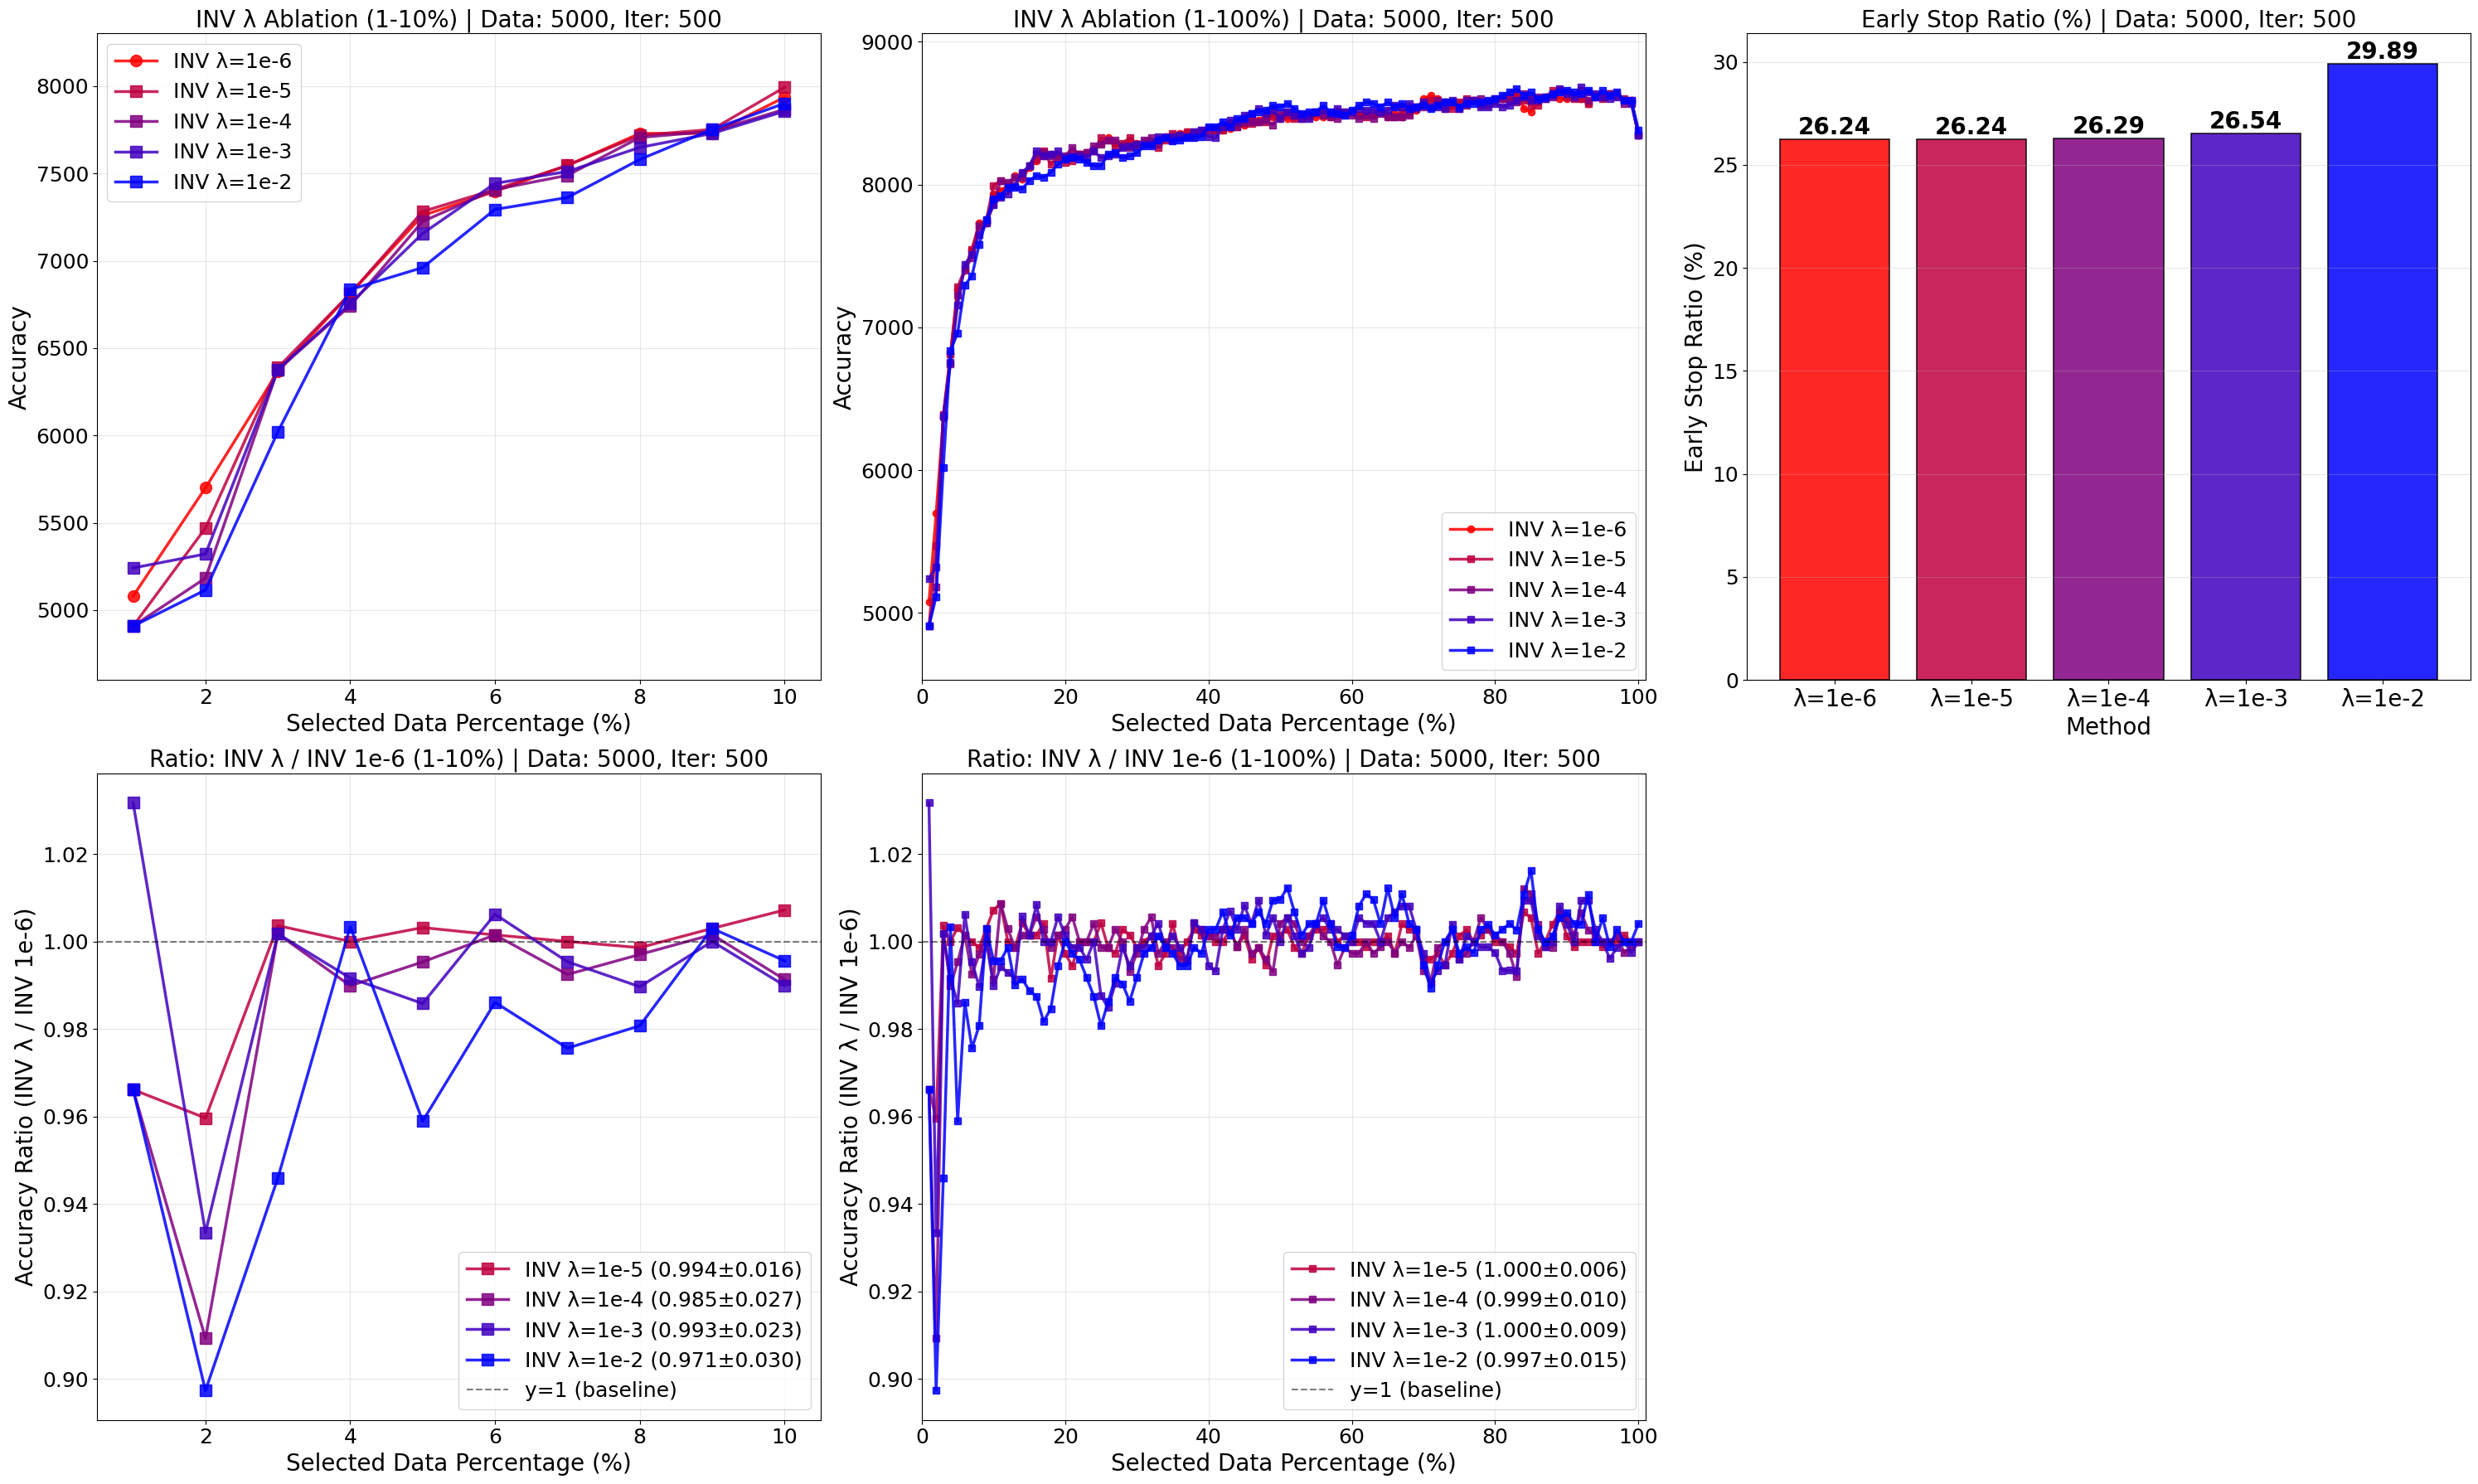

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors

# ===== Configuration =====
num_dp = 5000
iteration = 500
# =========================

selected_dp_percent = [i for i in range(1, 101)]

# inv lambda: variable, inv lambda: fixed(1e-6)
lam1e_6  = 
lam1e_5  = 
lam1e_4  = 
lam1e_3  = 
lam1e_2  = 

lam1e_6_early_stop = []
lam1e_5_early_stop = []
lam1e_4_early_stop = []
lam1e_3_early_stop = []
lam1e_2_early_stop = []

# ===== Color scheme: λ=1e-6 (red) ~ λ=1e-2 (blue) interpolation =====
color_1e_6 = np.array(mcolors.to_rgb('red'))
color_1e_2 = np.array(mcolors.to_rgb('blue'))

def interp_color(t):
    return tuple((1 - t) * color_1e_6 + t * color_1e_2)

# λ=1e-6: t=0 (red), λ=1e-5: t=0.25, λ=1e-4: t=0.5, λ=1e-3: t=0.75, λ=1e-2: t=1.0 (blue)
lam_colors = {
    '1e-6': interp_color(0.0),
    '1e-5': interp_color(0.25),
    '1e-4': interp_color(0.5),
    '1e-3': interp_color(0.75),
    '1e-2': interp_color(1.0),
}

# Data and labels for comparison (λ=1e-5 ~ 1e-2 vs baseline λ=1e-6)
inv_data = [
    (lam1e_5, 'INV λ=1e-5', lam_colors['1e-5']),
    (lam1e_4, 'INV λ=1e-4', lam_colors['1e-4']),
    (lam1e_3, 'INV λ=1e-3', lam_colors['1e-3']),
    (lam1e_2, 'INV λ=1e-2', lam_colors['1e-2']),
]

# Create figure with 6 subplots (2 rows, 3 columns)
fig, axes = plt.subplots(2, 3, figsize=(30, 18))
axes = axes.flatten()

plot_percent_10 = selected_dp_percent[:10]

# ===== Subplot (1,1): INV λ별 prediction accuracy, 1~10% =====
ax1 = axes[0]

ax1.plot(plot_percent_10, lam1e_6[:10], color=lam_colors['1e-6'], linewidth=2.5,
         linestyle='-', marker='o', markersize=10, label='INV λ=1e-6', alpha=0.85)

for data, label, color in inv_data:
    ax1.plot(plot_percent_10, data[:10], color=color, linewidth=2.5,
             linestyle='-', marker='s', markersize=10, label=label, alpha=0.85)

all_data_10 = [lam1e_6[:10]] + [d[0][:10] for d in inv_data]
y_min_10 = min([min(d) for d in all_data_10])
y_max_10 = max([max(d) for d in all_data_10])
y_margin_10 = (y_max_10 - y_min_10) * 0.1
ylim_10_min = y_min_10 - y_margin_10
ylim_10_max = y_max_10 + y_margin_10

ax1.set_xlabel('Selected Data Percentage (%)', fontsize=20)
ax1.set_ylabel('Accuracy', fontsize=20)
ax1.set_title(f'INV λ Ablation (1-10%) | Data: {num_dp}, Iter: {iteration}', fontsize=20)
ax1.legend(fontsize=18, loc='best')
ax1.grid(True, alpha=0.3)
ax1.set_xlim(0.5, 10.5)
ax1.set_ylim(ylim_10_min, ylim_10_max)
ax1.tick_params(axis='both', labelsize=18)

# ===== Subplot (1,2): INV λ별 prediction accuracy, 1~100% =====
ax2 = axes[1]

ax2.plot(selected_dp_percent, lam1e_6, color=lam_colors['1e-6'], linewidth=2.5,
         linestyle='-', marker='o', markersize=6, label='INV λ=1e-6', alpha=0.85)

for data, label, color in inv_data:
    ax2.plot(selected_dp_percent, data, color=color, linewidth=2.5,
             linestyle='-', marker='s', markersize=6, label=label, alpha=0.85)

all_data_100 = [lam1e_6] + [d[0] for d in inv_data]
y_min_100 = min([min(d) for d in all_data_100])
y_max_100 = max([max(d) for d in all_data_100])
y_margin_100 = (y_max_100 - y_min_100) * 0.1
ylim_100_min = y_min_100 - y_margin_100
ylim_100_max = y_max_100 + y_margin_100

ax2.set_xlabel('Selected Data Percentage (%)', fontsize=20)
ax2.set_ylabel('Accuracy', fontsize=20)
ax2.set_title(f'INV λ Ablation (1-100%) | Data: {num_dp}, Iter: {iteration}', fontsize=20)
ax2.legend(fontsize=18, loc='best')
ax2.grid(True, alpha=0.3)
ax2.set_xlim(0, 101)
ax2.set_ylim(ylim_100_min, ylim_100_max)
ax2.tick_params(axis='both', labelsize=18)

# ===== Subplot (1,3): Early Stop Ratio =====
ax3 = axes[2]

method_names = ['λ=1e-6', 'λ=1e-5', 'λ=1e-4', 'λ=1e-3', 'λ=1e-2']
method_values = [
    lam1e_6_early_stop[0],
    lam1e_5_early_stop[0],
    lam1e_4_early_stop[0],
    lam1e_3_early_stop[0],
    lam1e_2_early_stop[0],
]
bar_colors = [lam_colors['1e-6'], lam_colors['1e-5'], lam_colors['1e-4'], lam_colors['1e-3'], lam_colors['1e-2']]

x_pos = np.arange(len(method_names))
bars = ax3.bar(x_pos, method_values, color=bar_colors, alpha=0.85, edgecolor='black', linewidth=1.2)

for bar, value in zip(bars, method_values):
    height = bar.get_height()
    ax3.text(bar.get_x() + bar.get_width()/2., height,
             f'{value:.2f}', ha='center', va='bottom', fontsize=20, fontweight='bold')

ax3.set_xlabel('Method', fontsize=20)
ax3.set_ylabel('Early Stop Ratio (%)', fontsize=20)
ax3.set_title(f'Early Stop Ratio (%) | Data: {num_dp}, Iter: {iteration}', fontsize=20)
ax3.set_xticks(x_pos)
ax3.set_xticklabels(method_names, fontsize=20)
ax3.grid(True, alpha=0.3, axis='y')
ax3.tick_params(axis='y', labelsize=18)

# ===== Subplot (2,1): Ratio (INV 1e-X / INV 1e-6), 1~10% =====
ax4 = axes[3]

for data, label, color in inv_data:
    ratios = np.array(data[:10]) / np.array(lam1e_6[:10])
    ratio_mean = np.mean(ratios)
    ratio_std = np.std(ratios)
    ax4.plot(plot_percent_10, ratios, color=color, linewidth=2.5,
             linestyle='-', marker='s', markersize=10,
             label=f'{label} ({ratio_mean:.3f}±{ratio_std:.3f})', alpha=0.85)

ax4.axhline(y=1.0, color='black', linestyle='--', linewidth=1.5, alpha=0.5, label='y=1 (baseline)')

ax4.set_xlabel('Selected Data Percentage (%)', fontsize=20)
ax4.set_ylabel('Accuracy Ratio (INV λ / INV 1e-6)', fontsize=20)
ax4.set_title(f'Ratio: INV λ / INV 1e-6 (1-10%) | Data: {num_dp}, Iter: {iteration}', fontsize=20)
ax4.legend(fontsize=18, loc='best')
ax4.grid(True, alpha=0.3)
ax4.set_xlim(0.5, 10.5)
ax4.tick_params(axis='both', labelsize=18)

# ===== Subplot (2,2): Ratio (INV 1e-X / INV 1e-6), 1~100% =====
ax5 = axes[4]

for data, label, color in inv_data:
    ratios = np.array(data) / np.array(lam1e_6)
    ratio_mean = np.mean(ratios)
    ratio_std = np.std(ratios)
    ax5.plot(selected_dp_percent, ratios, color=color, linewidth=2.5,
             linestyle='-', marker='s', markersize=6,
             label=f'{label} ({ratio_mean:.3f}±{ratio_std:.3f})', alpha=0.85)

ax5.axhline(y=1.0, color='black', linestyle='--', linewidth=1.5, alpha=0.5, label='y=1 (baseline)')

ax5.set_xlabel('Selected Data Percentage (%)', fontsize=20)
ax5.set_ylabel('Accuracy Ratio (INV λ / INV 1e-6)', fontsize=20)
ax5.set_title(f'Ratio: INV λ / INV 1e-6 (1-100%) | Data: {num_dp}, Iter: {iteration}', fontsize=20)
ax5.legend(fontsize=18, loc='best')
ax5.grid(True, alpha=0.3)
ax5.set_xlim(0, 101)
ax5.tick_params(axis='both', labelsize=18)

# ===== Subplot (2,3): Turn off unused subplot =====
axes[5].axis('off')

plt.tight_layout()
plt.show()

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors

# ===== Configuration =====
num_dp = 10000
iteration = 500
# =========================

selected_dp_percent = [i for i in range(1, 101)]

# inv lambda: variable, inv lambda: fixed(1e-6)
lam1e_6  = 
lam1e_5  = 
lam1e_4  = 
lam1e_3  = 
lam1e_2  = 

lam1e_6_early_stop = []
lam1e_5_early_stop = []
lam1e_4_early_stop = []
lam1e_3_early_stop = []
lam1e_2_early_stop = []

# ===== Color scheme: λ=1e-6 (red) ~ λ=1e-2 (blue) interpolation =====
color_1e_6 = np.array(mcolors.to_rgb('red'))
color_1e_2 = np.array(mcolors.to_rgb('blue'))

def interp_color(t):
    return tuple((1 - t) * color_1e_6 + t * color_1e_2)

# λ=1e-6: t=0 (red), λ=1e-5: t=0.25, λ=1e-4: t=0.5, λ=1e-3: t=0.75, λ=1e-2: t=1.0 (blue)
lam_colors = {
    '1e-6': interp_color(0.0),
    '1e-5': interp_color(0.25),
    '1e-4': interp_color(0.5),
    '1e-3': interp_color(0.75),
    '1e-2': interp_color(1.0),
}

# Data and labels for comparison (λ=1e-5 ~ 1e-2 vs baseline λ=1e-6)
inv_data = [
    (lam1e_5, 'INV λ=1e-5', lam_colors['1e-5']),
    (lam1e_4, 'INV λ=1e-4', lam_colors['1e-4']),
    (lam1e_3, 'INV λ=1e-3', lam_colors['1e-3']),
    (lam1e_2, 'INV λ=1e-2', lam_colors['1e-2']),
]

# Create figure with 6 subplots (2 rows, 3 columns)
fig, axes = plt.subplots(2, 3, figsize=(30, 18))
axes = axes.flatten()

plot_percent_10 = selected_dp_percent[:10]

# ===== Subplot (1,1): INV λ별 prediction accuracy, 1~10% =====
ax1 = axes[0]

ax1.plot(plot_percent_10, lam1e_6[:10], color=lam_colors['1e-6'], linewidth=2.5,
         linestyle='-', marker='o', markersize=10, label='INV λ=1e-6', alpha=0.85)

for data, label, color in inv_data:
    ax1.plot(plot_percent_10, data[:10], color=color, linewidth=2.5,
             linestyle='-', marker='s', markersize=10, label=label, alpha=0.85)

all_data_10 = [lam1e_6[:10]] + [d[0][:10] for d in inv_data]
y_min_10 = min([min(d) for d in all_data_10])
y_max_10 = max([max(d) for d in all_data_10])
y_margin_10 = (y_max_10 - y_min_10) * 0.1
ylim_10_min = y_min_10 - y_margin_10
ylim_10_max = y_max_10 + y_margin_10

ax1.set_xlabel('Selected Data Percentage (%)', fontsize=20)
ax1.set_ylabel('Accuracy', fontsize=20)
ax1.set_title(f'INV λ Ablation (1-10%) | Data: {num_dp}, Iter: {iteration}', fontsize=20)
ax1.legend(fontsize=18, loc='best')
ax1.grid(True, alpha=0.3)
ax1.set_xlim(0.5, 10.5)
ax1.set_ylim(ylim_10_min, ylim_10_max)
ax1.tick_params(axis='both', labelsize=18)

# ===== Subplot (1,2): INV λ별 prediction accuracy, 1~100% =====
ax2 = axes[1]

ax2.plot(selected_dp_percent, lam1e_6, color=lam_colors['1e-6'], linewidth=2.5,
         linestyle='-', marker='o', markersize=6, label='INV λ=1e-6', alpha=0.85)

for data, label, color in inv_data:
    ax2.plot(selected_dp_percent, data, color=color, linewidth=2.5,
             linestyle='-', marker='s', markersize=6, label=label, alpha=0.85)

all_data_100 = [lam1e_6] + [d[0] for d in inv_data]
y_min_100 = min([min(d) for d in all_data_100])
y_max_100 = max([max(d) for d in all_data_100])
y_margin_100 = (y_max_100 - y_min_100) * 0.1
ylim_100_min = y_min_100 - y_margin_100
ylim_100_max = y_max_100 + y_margin_100

ax2.set_xlabel('Selected Data Percentage (%)', fontsize=20)
ax2.set_ylabel('Accuracy', fontsize=20)
ax2.set_title(f'INV λ Ablation (1-100%) | Data: {num_dp}, Iter: {iteration}', fontsize=20)
ax2.legend(fontsize=18, loc='best')
ax2.grid(True, alpha=0.3)
ax2.set_xlim(0, 101)
ax2.set_ylim(ylim_100_min, ylim_100_max)
ax2.tick_params(axis='both', labelsize=18)

# ===== Subplot (1,3): Early Stop Ratio =====
ax3 = axes[2]

method_names = ['λ=1e-6', 'λ=1e-5', 'λ=1e-4', 'λ=1e-3', 'λ=1e-2']
method_values = [
    lam1e_6_early_stop[0],
    lam1e_5_early_stop[0],
    lam1e_4_early_stop[0],
    lam1e_3_early_stop[0],
    lam1e_2_early_stop[0],
]
bar_colors = [lam_colors['1e-6'], lam_colors['1e-5'], lam_colors['1e-4'], lam_colors['1e-3'], lam_colors['1e-2']]

x_pos = np.arange(len(method_names))
bars = ax3.bar(x_pos, method_values, color=bar_colors, alpha=0.85, edgecolor='black', linewidth=1.2)

for bar, value in zip(bars, method_values):
    height = bar.get_height()
    ax3.text(bar.get_x() + bar.get_width()/2., height,
             f'{value:.2f}', ha='center', va='bottom', fontsize=20, fontweight='bold')

ax3.set_xlabel('Method', fontsize=20)
ax3.set_ylabel('Early Stop Ratio (%)', fontsize=20)
ax3.set_title(f'Early Stop Ratio (%) | Data: {num_dp}, Iter: {iteration}', fontsize=20)
ax3.set_xticks(x_pos)
ax3.set_xticklabels(method_names, fontsize=20)
ax3.grid(True, alpha=0.3, axis='y')
ax3.tick_params(axis='y', labelsize=18)

# ===== Subplot (2,1): Ratio (INV 1e-X / INV 1e-6), 1~10% =====
ax4 = axes[3]

for data, label, color in inv_data:
    ratios = np.array(data[:10]) / np.array(lam1e_6[:10])
    ratio_mean = np.mean(ratios)
    ratio_std = np.std(ratios)
    ax4.plot(plot_percent_10, ratios, color=color, linewidth=2.5,
             linestyle='-', marker='s', markersize=10,
             label=f'{label} ({ratio_mean:.3f}±{ratio_std:.3f})', alpha=0.85)

ax4.axhline(y=1.0, color='black', linestyle='--', linewidth=1.5, alpha=0.5, label='y=1 (baseline)')

ax4.set_xlabel('Selected Data Percentage (%)', fontsize=20)
ax4.set_ylabel('Accuracy Ratio (INV λ / INV 1e-6)', fontsize=20)
ax4.set_title(f'Ratio: INV λ / INV 1e-6 (1-10%) | Data: {num_dp}, Iter: {iteration}', fontsize=20)
ax4.legend(fontsize=18, loc='best')
ax4.grid(True, alpha=0.3)
ax4.set_xlim(0.5, 10.5)
ax4.tick_params(axis='both', labelsize=18)

# ===== Subplot (2,2): Ratio (INV 1e-X / INV 1e-6), 1~100% =====
ax5 = axes[4]

for data, label, color in inv_data:
    ratios = np.array(data) / np.array(lam1e_6)
    ratio_mean = np.mean(ratios)
    ratio_std = np.std(ratios)
    ax5.plot(selected_dp_percent, ratios, color=color, linewidth=2.5,
             linestyle='-', marker='s', markersize=6,
             label=f'{label} ({ratio_mean:.3f}±{ratio_std:.3f})', alpha=0.85)

ax5.axhline(y=1.0, color='black', linestyle='--', linewidth=1.5, alpha=0.5, label='y=1 (baseline)')

ax5.set_xlabel('Selected Data Percentage (%)', fontsize=20)
ax5.set_ylabel('Accuracy Ratio (INV λ / INV 1e-6)', fontsize=20)
ax5.set_title(f'Ratio: INV λ / INV 1e-6 (1-100%) | Data: {num_dp}, Iter: {iteration}', fontsize=20)
ax5.legend(fontsize=18, loc='best')
ax5.grid(True, alpha=0.3)
ax5.set_xlim(0, 101)
ax5.tick_params(axis='both', labelsize=18)

# ===== Subplot (2,3): Turn off unused subplot =====
axes[5].axis('off')

plt.tight_layout()
plt.show()